# Illustration of Phase Precession in the Model with Different Theta Conditions

In [1]:
# Imports
import sys # for path management
sys.path.insert(0, "/Users/liviastein/STDP_Theta-1/STDP-SR_scripts")  # Ensure current directory is in path
from MazeAgent_Script import *  # import all functions from MazeAgent_Script
import copy
import tomplotlib.tomplotlib as tpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

%load_ext autoreload
%autoreload 2

#for plotting in notebook
%matplotlib inline  

### Define MazeAgent Parameters

Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   initialising theta phases: clean and scrambled
   making the maze walls
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


  0%|          | 0/10000 [00:00<?, ?it/s]

   initialising STDP weight matrix and traces
Adding 'theta scrambled' Condition
DONE


(<Figure size 4000x160 with 1 Axes>, <Axes: >)

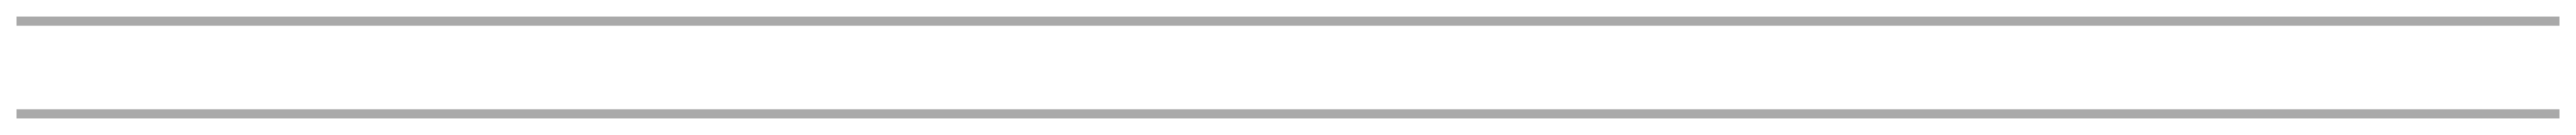

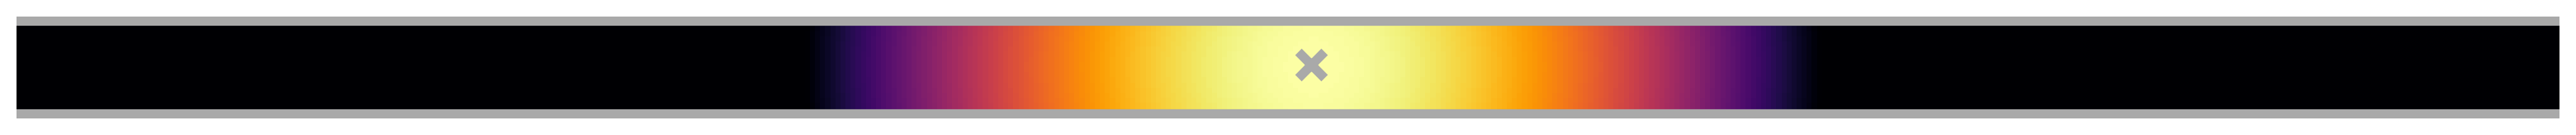

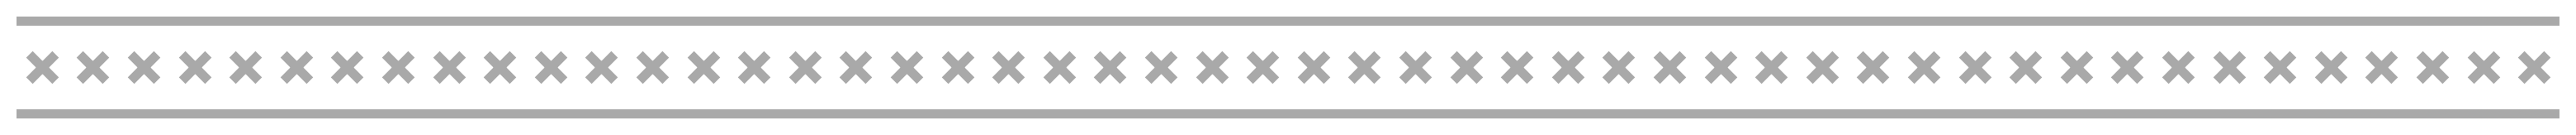

In [8]:
## Define parameters for maze and agent
# number of placeCells
N=50

# set x and y coordinates for place cell centres
xcen = np.linspace(0,5,N+1)[:-1] # we want to place N place cells evenly across the 5m length of the maze, so we create N+1 evenly spaced points and then take all but the last one (which is at 5m) to get the centres of the place cells.
xcen += (xcen[1] - xcen[0]) / 2 # we want the first place cell to be centred at 0.1m, so we shift all the centres by half the distance between them (i.e. the distance between the first centre and 0m) to get the final x coordinates of the place cell centres.
ycen = np.array([0.1]*N) # we want all the place cells to be centred at 0.1m in the y direction (i.e. 10cm from the south wall) so we set all the y coordinates of the place cell centres to 0.1m.
centres = np.vstack((xcen,ycen)).T # we combine the x and y coordinates into a single array of shape (N,2) where each row is the (x,y) coordinates of a place cell centre.

# set parameters for the MazeAgent class
params = {
           #Maze params 
          'mazeType'            : 'loop',  #type of maze, define in getMaze() function
          'stateType'           : 'gaussianThreshold', #feature on which to TD learn (onehot, gaussian, gaussianCS, circles, bump)
          'movementPolicy'      : 'windowsScreensaver',  #movement policy (raudies, random walk, windows screensaver)
          'roomSize'            : 5,          #maze size scaling parameter, metres
          'dt'                  : 0.005,       #simulation time disretisation (defualts to largest )
          'dx'                  : 0.01,       #space discretisation (for plotting, movement is continuous)
          'speedScale'          : 0.16,       #movement speed scale, metres/second
          'rotSpeedScale'       : None,       #rotational speed scale, radians/second
          'initPos'             : None,  #initial position [x0, y0], metres
          'initDir'             : None,      #initial direction, unit vector
          'nCells'              : N,       #how many features to use
          'centres'             : centres,       #array of receptive field positions. Overwrites nCells
          'sigma'               : 1,          #basis cell width scale (irrelevant for onehots)
          'doorsClosed'         : False,       #whether doors are opened or closed in multicompartment maze
          'reorderCells'        : True,       #whether to reorde the cell centres which have been provided
          'firingRateLookUp'    : False,      #use quantised lookup table for firing rates 
          'biasDoorCross'       : False,      #if True, in twoRoom maze door crossings are biased towards
          'biasWallFollow'      : True,       #if True, agent aligns to wall when gets too near.

          #TD params 
          'tau'                 : 4,          #TD decay time, seconds
          'TDdx'                : 0.1,       #rough distance between TD learning updates, metres 
          'alpha'               : 0.01,       #TD learning rate 
          'successorFeatureNorm': 100,        #linear scaling on successor feature definition found to improve learning stability
          'TDreg'               : 0.01,       #L2 regularisation 
          
          #STDP params
          'peakFiringRate'      : 5,          #peak firing rate of a cell (middle of place field,preferred theta phase)
          'tau_STDP_plus'       : 20e-3,      #pre trace decay time
          'tau_STDP_minus'      : 40e-3,      #post trace decay time
          'a_STDP'              : -0.4,       #pre-before-post potentiation factor (post-before-pre = 1) 
          'eta'                 : 0.01,       #STDP learning rate
          'baselineFiringRate'  : 0,          #baseline firing rate for cells 
          'use_full_STDP_rule'  : True,      #whether to use full STDP rule     
          'online_mapping'      : 'identity',  #how to map CA3-->CA1 during learning
          'rownorm'             : False,

          #Theta precession params
          'thetaFreq'           : 10,         #theta frequency
          'precessFraction'     : 0.5,        #fraction of 2pi the prefered phase moves through
          'kappa'               : 0.5,          # von mises spread parameter
          
          #Theta scrambling params (Livi addition)
          'scramble_strength'    : 1.0,        # strength of theta phase scrambling 
          'hf_strength'          : 1.0,        # strength of high frequency jitter added to scrambled theta phase

}

agent_p = MazeAgent(params)
plotter = Visualiser(agent_p)
agent_p.toggleDoors(params['doorsClosed'])

plotter.plotMazeStructure() # plot maze structure to check it's correct before starting simulation
plotter.plotReceptiveField(25) # plot receptive field of place cell 25 in the middel of loop
plotter.plotFeatureCells(centresOnly=True, textlabel=False) # plots centres of the place cells in maze (no heatmap)


### Simulation Loop and Plots

  0%|          | 0/360000 [00:00<?, ?it/s]

Calculating place and grid cells


(<Figure size 400x400 with 2 Axes>,
 <Axes: title={'center': "TD matrix 'M' after 30min of TD learning"}>,
 <Axes: >)

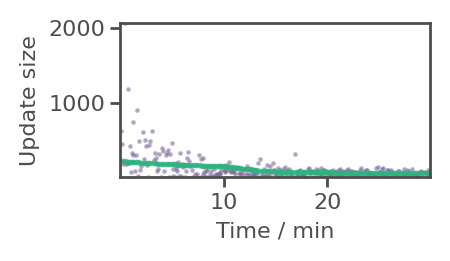

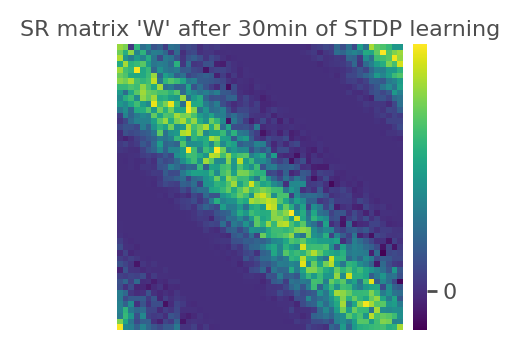

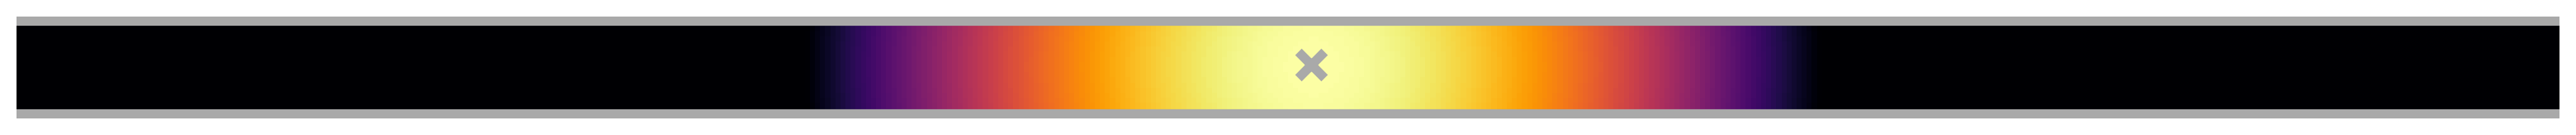

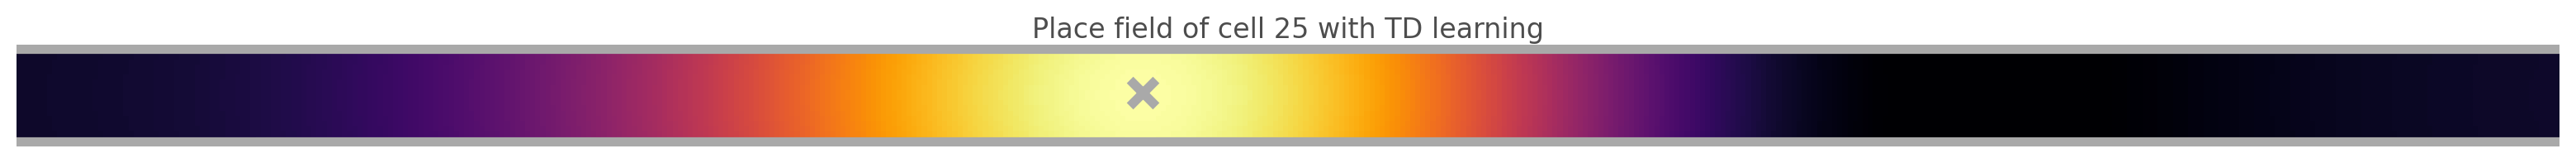

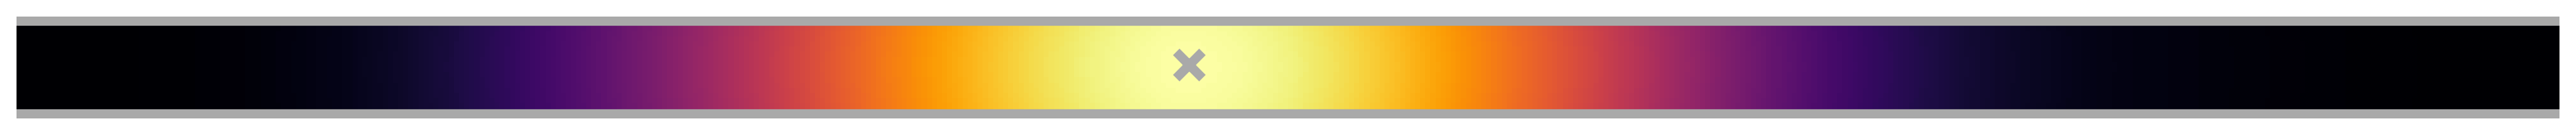

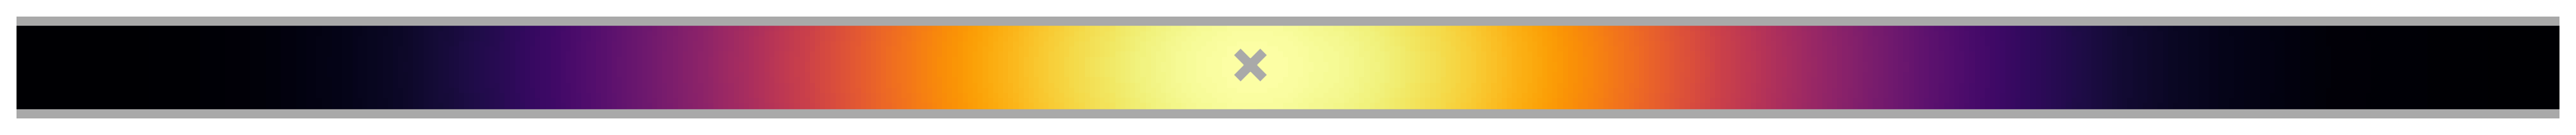

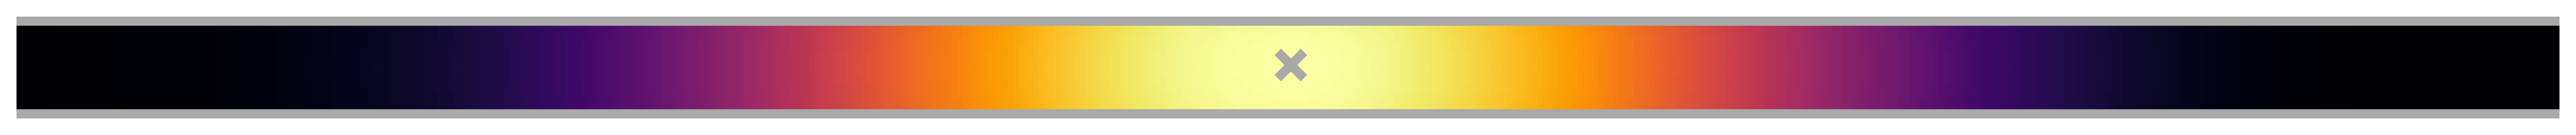

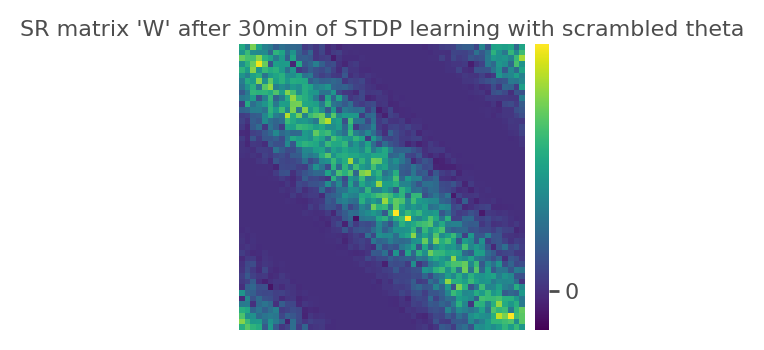

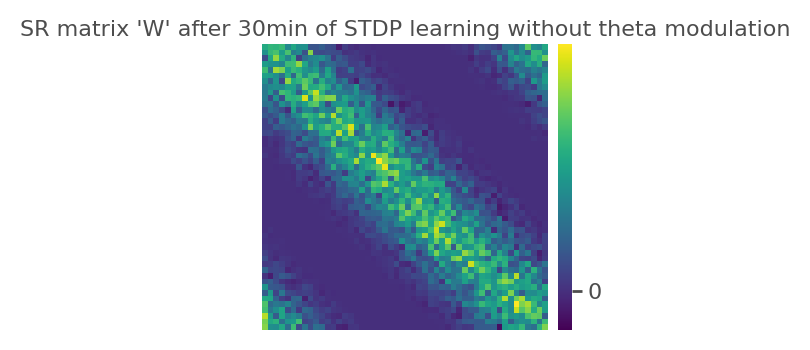

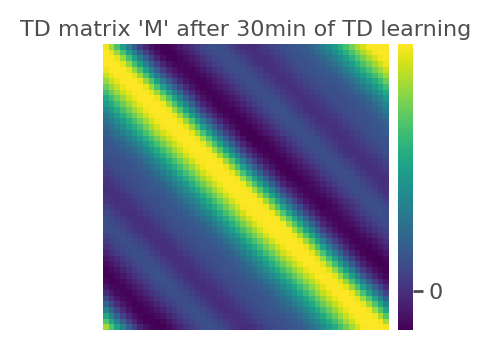

In [9]:
# Set parameters and run simulation
agent_p.pos = np.array([0,0.1])  
agent_p.dir = np.array([1,0]) # start at the west end of the loop, facing east, so we can follow the walls in a clockwise direction

# Define agent to train for 30min (as in paper), with STDP learning, no TD learning and save snapshots every 1min
model1= agent_p.runRat(trainTime=30, STDPLearn=True, TDSRLearn=True, saveEvery=0.5)
model1

# Define what to plot from this STDP run
plotter = Visualiser(agent_p) # create new plotter to access the data from the STDP run we just did

# PLOTTING
# plot STDP weight matrix 'W' with clean theta
plotter.plotM(whichM="W", colorbar=True, title="SR matrix 'W' after 30min of STDP learning", save=True)
# plot basis feature again
plotter.plotReceptiveField(25)

# plot place field of cell 25 with TD learning 
fig, ax=plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=False, threshold=0.0)
ax.set_title("Place field of cell 25 with TD learning", fontsize=12)

# plot place field of cell 25 with STDP learning (clean theta)
plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=True, no_theta=False, threshold=0.0)

# plot place field of cell 25 with STDP learning but no theta modulation 
plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=True, no_theta=True, threshold=0.0)

# scrambled that place field of cell 25 with STDP learning but no theta modulation
plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=True, no_theta=False, scrambled=True, threshold=0.0)

# Plot scrambled
plotter.plotM(whichM="W_scrambled", colorbar=True, title="SR matrix 'W' after 30min of STDP learning with scrambled theta", save=True) 

# Plot no_theta
plotter.plotM(whichM="W_notheta", colorbar=True, title="SR matrix 'W' after 30min of STDP learning without theta modulation", save=True)

# Plot TD plots
plotter.plotM(whichM="M", colorbar=True, title="TD matrix 'M' after 30min of TD learning", save=True)


# Plot combined plots 
#plotter.plotMAveraged(time=None, x_ticks=None, plot_no_theta=True, color='C7',ylim=None, renorm=True, return_data=True)
#plotter.plotMetrics(total_time=None, x_ticks=None)

## Plot Phase Precession for Clean and Scrambled Theta Condition
Theoretically one could also create the plot for the no theta condition, but there is no theta, meaning that in the bottom plot there is just a horizontal line instead of scattered points, bcs theta phase is on the y-axis but there is no phase in that condition. Hence, only Clean and scrambled theta will be plotted here.

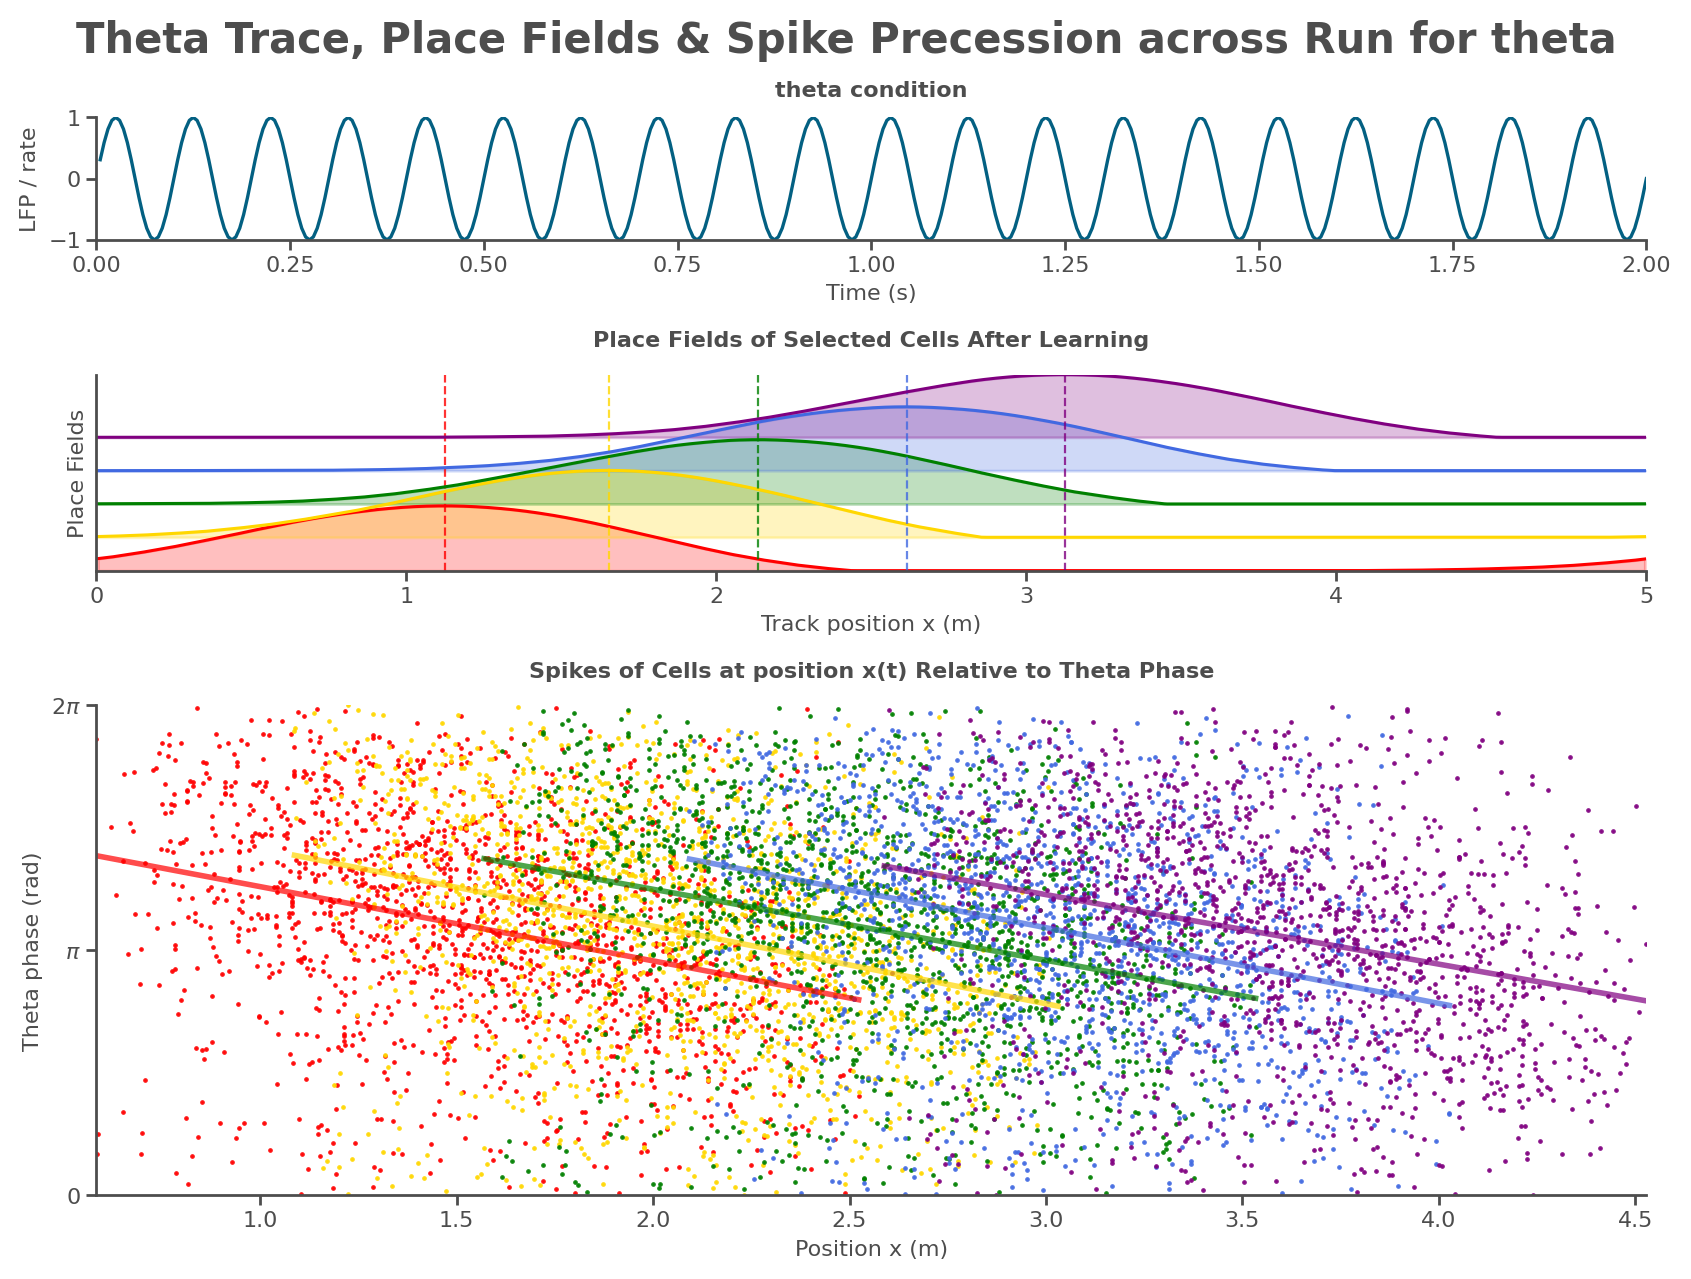

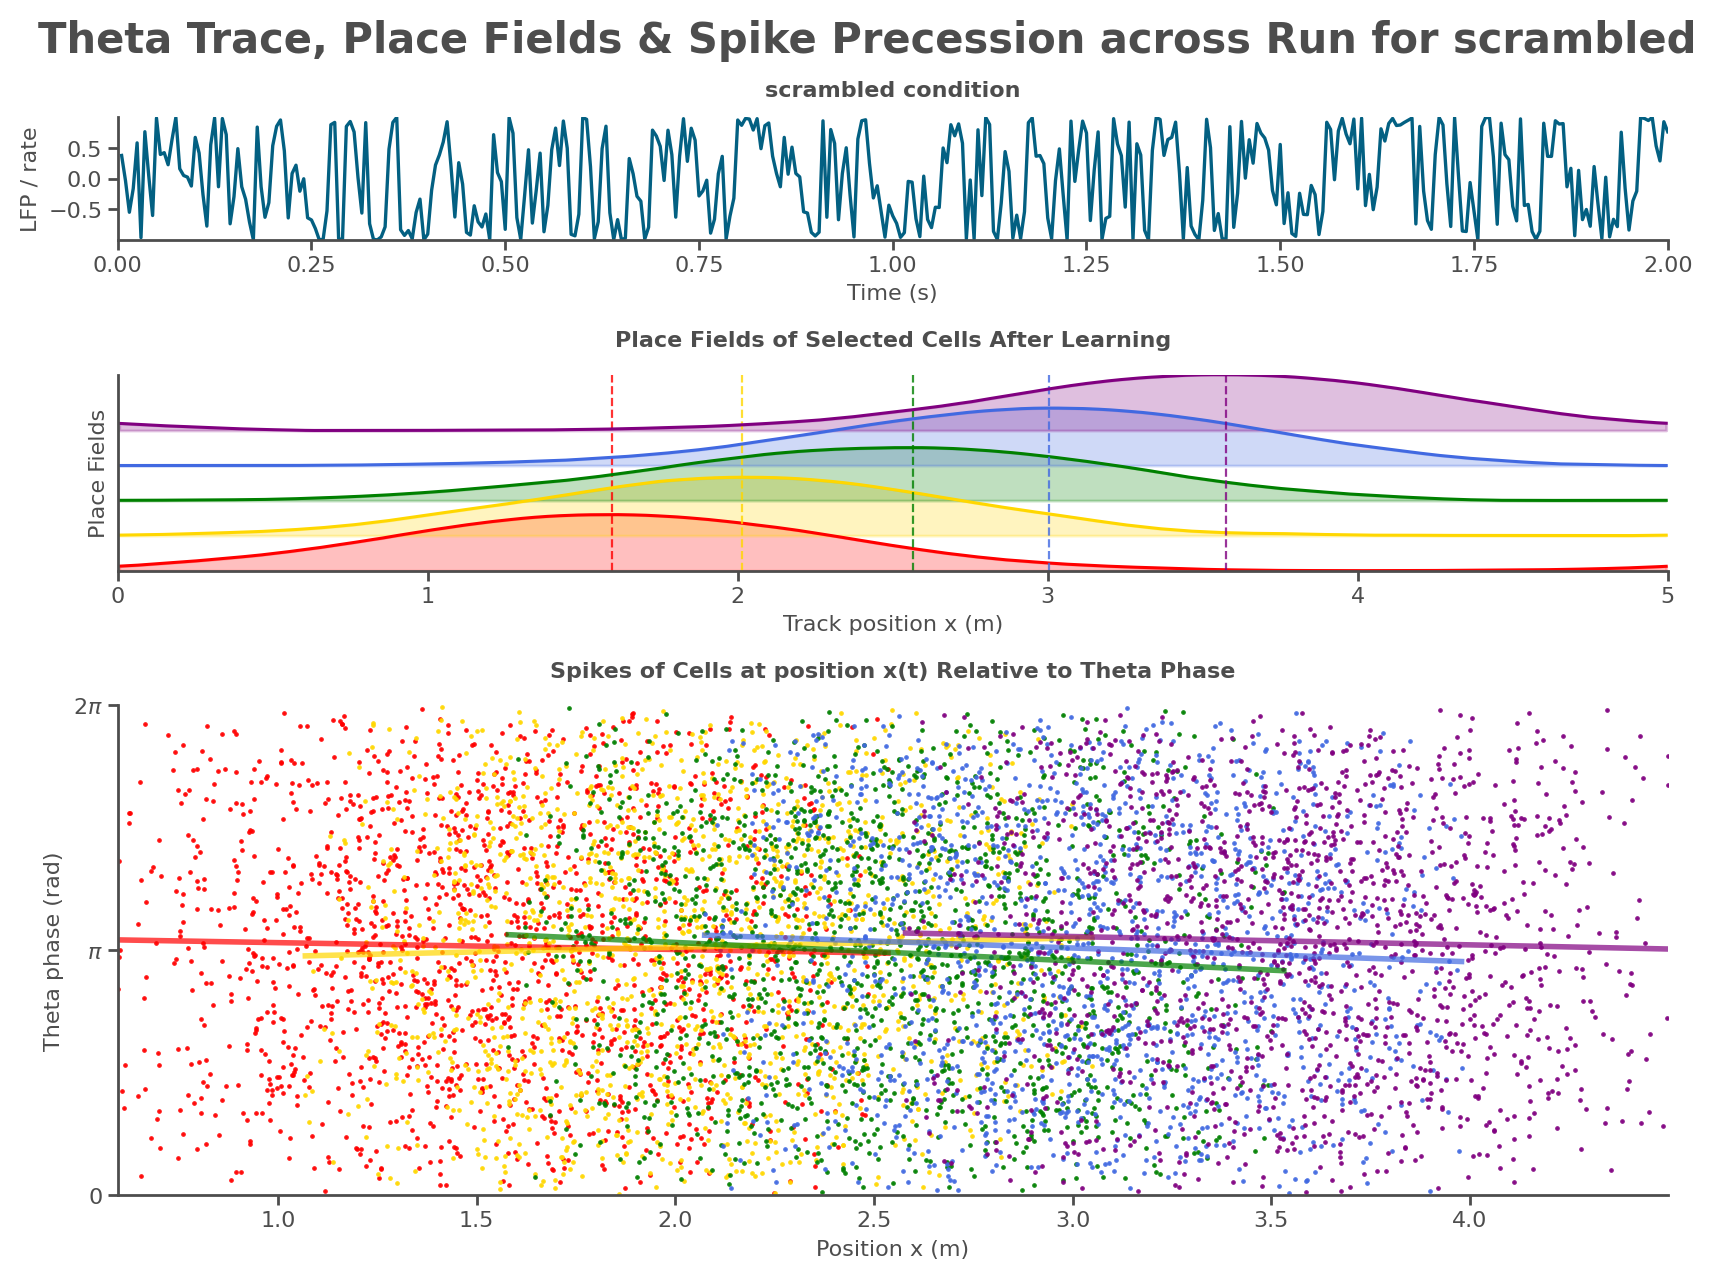

{np.int64(15): np.float64(1.5949999999999998),
 np.int64(20): np.float64(2.0149999999999997),
 np.int64(25): np.float64(2.5649999999999995),
 np.int64(30): np.float64(3.0049999999999994),
 np.int64(35): np.float64(3.5749999999999993)}

In [4]:
# FUNCTION TO PLOT PHASE PRECESSION FOR DIFFERENT THETA CONDITIONS -> clean and scrambled

def plot_sequence_scatter(cond_key = "theta", phase_hist=None, agent=agent_p, selectedCells=None, save_name= None, fig= None, ax = None):
    """
    Plots three different plots stacked vertically:
    1. Top plot: LFP signal trace for a specific time window to show theta condition 
    2. Middle plot: the field silhouettes of the 5 selected cells for the selected theta condition
    3. Bottom plot: scatter plot of theta phase (0-2pi) vs position on the track for the spikes of the 5 selected cells 
    for a specific time window of the agent running in the 1D loop
    """
    # SELECT CELLS TO PLOT PLACE FIELDS FOR IN BOTTOM SCATTER PLOT and ABOVE
    if selectedCells is None or len(selectedCells) == 0:
        selected_cells = np.array([15, 20, 25, 30, 35], dtype=int)
    else:
        selected_cells = np.array(selectedCells, dtype=int)

    # define colors and labels for the 5 cells we will plot (A-E)
    colors = ["red", "gold", "green", "royalblue", "purple"]
    labels = ["A", "B", "C", "D", "E"]
    
    # Define subplot
    fig, (ax_top, ax_mid, ax_bot) = plt.subplots(
        3, 1, figsize=(10,7), gridspec_kw={"height_ratios": [0.5, 0.8, 2]}, constrained_layout=False
    )
    fig.subplots_adjust(hspace=0.5, wspace=0.3)

    # VARIABLES BOTTOM PLOT
    # ----------------------
    # Set up the data for plotting
    t_history = agent.history["t"].to_numpy(dtype=float)
    pos_history = np.vstack(agent.history["pos"].to_numpy())  # shape (T,2)

    # VARIABLES TOP PLOT
    # ----------------------
    # clean theta phase: not stored as full history in this script -> reconstruct from time
    if phase_hist == "theta":
        thetaPhase_history = np.mod(2 * np.pi * agent.thetaFreq * t_history, 2*np.pi)
        phase_hist = thetaPhase_history # we will use this in the top plot to plot the LFP trace
    
    elif phase_hist == "notheta":
    # no theta modulation condition -> flat phase at pi/2 (peak of theta) to show that there is no modulation; adjust as needed if you want a different flat phase
        thetaPhase_notheta_history = np.full_like(t_history, np.pi/2) 
        phase_hist = thetaPhase_notheta_history # we will use this in the top plot to plot the LFP trace
    
    elif phase_hist == "scrambled":
    # scrambled phase history (stored during scrambled modulation)
        thetaPhase_scrambled_history = np.asarray(agent.thetaPhase_scrambled_history, dtype=float).reshape(-1)
        if thetaPhase_scrambled_history.ndim > 1: # .ndim means "number of dimensions" -> if it's more than 1D, we take the first column (assuming shape is (T,1))
            thetaPhase_scrambled_history = thetaPhase_scrambled_history[:, 0]
        thetaPhase_scrambled_history = np.mod(thetaPhase_scrambled_history, 2*np.pi) # np.mod ensures all phases are wrapped to [0, 2pi] bcs we want to plot them on a circular axis later
        phase_hist = thetaPhase_scrambled_history # we will use this in the top plot to plot the LFP trace

    # align lengths safely (because we have some time points where scrambled theta is not stored, so we take the min length across all histories to avoid indexing errors)
    n = min(len(t_history), len(pos_history), len(phase_hist))
    t_history = t_history[:n]
    pos_history = pos_history[:n]
    phase_hist = phase_hist[:n]

    # VARIABLES MIDDLE PLOT
    # ----------------------
    hist_id = agent.snapshots['t'].sub(30*60).abs().to_numpy().argmin()
    snapshot = agent.snapshots.iloc[hist_id-22]
     
    if cond_key == "theta":
        M_use = snapshot["W"]
    elif cond_key == "notheta":
        M_use = snapshot["W_notheta"]
    elif cond_key == "scrambled":
        M_use = snapshot["W_scrambled"]
    else:
        raise ValueError(f"Unknown cond_key: {cond_key}")   

    x = agent.discreteCoords[10,:,0]
    L = agent.roomSize
    pf_all = agent.getPlaceFields(M=M_use, threshold=0)

    learned_centres = {}
    for i, cell_id in enumerate(selected_cells):
        y = pf_all[cell_id, 10, :].copy()
        area = np.trapezoid(y, x)
        if area > 0:
            y = y / area

        # learned centre after learning (choose peak; robust and simple)
        mu_learned = x[np.argmax(y)]
        learned_centres[cell_id] = mu_learned

        y_off = i * 0.35
        ax_mid.fill_between(x, y_off, y + y_off, color=colors[i], alpha=0.25)
        ax_mid.plot(x, y + y_off, color=colors[i], lw=1.1, label=labels[i])
        ax_mid.axvline(mu_learned, color=colors[i], lw=0.8, ls="--", alpha=0.8)

    ax_mid.set_xlim(0, L)
    ax_mid.set_xlabel("Track position x (m)")
    ax_mid.set_ylabel("Place Fields")
    ax_mid.set_title("Place Fields of Selected Cells After Learning", fontweight='bold', y=1.1)
    ax_mid.set_yticks([])
    ax_mid.spines["top"].set_visible(False)
    ax_mid.spines["right"].set_visible(False)
    
    # ---------------------
    # CREATE MASKS FOR DIFFERENT TIME WINDOWS

    # SETTNGS FOR MASK FOR BOTTOM PLOT
    t_start_b, t_end_b = 500.0, 3600.0
    mask_t_b = (t_history >= t_start_b) & (t_history <= t_end_b)
    t_win_b = t_history[mask_t_b]
    x_win_b = pos_history[mask_t_b, 0] # 0 is x-coordinate; we will plot phase vs x-position, so we only need the x-coordinate here

    # SETTINGS MASK MIDDLE PLOT
    t_start_m, t_end_m = 0.0, 30.0
    mask_t_m = (t_history >= t_start_m) & (t_history <= t_end_m)
    t_win_m = t_history[mask_t_m]
    x_win_m = pos_history[mask_t_m, 0]

    # SETTINGS MASK LFP PLOT
    t_start_lfp, t_end_lfp = 0.0, 2.0
    mask_t_lfp = (t_history >= t_start_lfp) & (t_history <= t_end_lfp)
    t_win_lfp = t_history[mask_t_lfp]
    x_win_lfp = pos_history[mask_t_lfp, 0]


    # TOP PLOT: LFP
    lfp = np.sin(phase_hist[mask_t_lfp])
    ax_top.plot(t_win_lfp, lfp, color="#036082", lw=1.2)

    ax_top.set_xlim(t_start_lfp, t_end_lfp)
    ax_top.set_ylabel("LFP / rate")
    ax_top.set_xlabel("Time (s)")
    ax_top.set_title(f"{cond_key} condition", fontweight='bold', y= 1.1)
    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)

    # BOTTOM PLOT: phase-position scatter (main plot)
    sp = agent.spikedata_by_condition[cond_key]["CA1"] # get spike data for this condition and CA3 cells; adjust key if your data structure is different
    spike_times_all = np.asarray(sp["times"], dtype=float) # get all spike times for this condition and CA1 cells; adjust key if your data structure is different
    spike_ids_all = np.asarray(sp["ids"], dtype=int) # get all spike cell IDs for this condition and CA1 cells; adjust key if your data structure is different

    for i, cell_id in enumerate(selected_cells):
        cell_mask = (spike_ids_all == cell_id) # boolean mask to select spikes from this cell
        st = spike_times_all[cell_mask] # spike times for this cell
        st = st[(st >= t_start_b) & (st <= t_end_b)] # further mask to select spikes within the time window; adjust t_start and t_end as needed
        if st.size == 0: # if there are no spikes for this cell in the time window, skip to avoid errors in interpolation
            continue
        
        # interpolate position and phase at spike times; np.interp will give us the position and phase at the exact spike times based on the recorded history, which we can then plot in the scatter plot
        pos_at_spike = np.interp(st, t_history, pos_history[:, 0]) # position (x-coordinate) at spike times
        phase_at_spike = np.mod(np.interp(st, t_history, phase_hist), 2*np.pi) # phase at spike times, wrapped to [0, 2pi] for circular plotting

        # plot spikes for this cell in the scatter plot with the corresponding color and label
        ax_bot.scatter(pos_at_spike, phase_at_spike, c=colors[i], s=0.5, alpha=0.9, label=labels[i])

        # ADD REGRESSION LINE (# to remove)
        if len(pos_at_spike) > 1:  # need at least 2 points
            slope, intercept, r_value, p_value, std_err = stats.linregress(pos_at_spike, phase_at_spike)
            x_line = np.linspace(pos_at_spike.min(), pos_at_spike.max(), 100)
            y_line = slope * x_line + intercept
            ax_bot.plot(x_line, y_line, color=colors[i], lw=2.0, linestyle='-', alpha=0.7)

    ax_bot.set_xlabel("Position x (m)")
    ax_bot.set_ylabel("Theta phase (rad)")
    ax_bot.set_title("Spikes of Cells at position x(t) Relative to Theta Phase", fontweight='bold', y=1.04)
    ax_bot.set_ylim(0, 2*np.pi)
    ax_bot.set_yticks([0, np.pi, 2*np.pi])
    ax_bot.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])
    ax_bot.spines["top"].set_visible(False)
    ax_bot.spines["right"].set_visible(False)

    plt.suptitle(f'Theta Trace, Place Fields & Spike Precession across Run for {cond_key}', fontsize=15, fontweight='bold', y=0.95)

    #fig.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    return learned_centres

# theta
plot_sequence_scatter(cond_key = "theta", phase_hist= "theta", agent=agent_p, selectedCells=[15, 20, 25, 30, 35], save_name= None, fig= None, ax = None)
# scrambled (key is 'scrambled' in your code)
plot_sequence_scatter(cond_key = "scrambled", phase_hist= "scrambled", agent=agent_p, selectedCells=None, save_name= None, fig= None, ax = None)
# no theta modulation but doesn't really make sense to plot bcs there is no theta phase
# plot_sequence_scatter(cond_key = "notheta", phase_hist= "notheta", agent=agent_p, selectedCells=None, save_name= None, fig= None, ax = None)


## Second Plot: Individual Spikes Relative to Theta Phase in a Specific Time Window

This second plot does however not show clear theta sequences in the specific time bins for each theta cycle. In their paper, George et al. (2023) state that "In our model phase, precession generates theta sweeps (Figure 1a, grey box) as cells successively visited along the current trajectory fire at progressively later times in each theta cycle. Theta sweeps take the current trajectory of the agent and effectively compress it in time. As we show below these compressed trajectories are important for learning successor features." In theory this i plausible, since in their model phase precession means that the preferred phase of a cell moves to earlier and earlier phases of the global theta oscillation as the agent traverses the receptive field. On the population level for a single cycle at any position of the agent at time t (x(t)), this hence means that the preferred phase of cells behind the agent is earlier in the cycle, while cells in front of the agent have there preferred phase progressivly later in the cycle the more they are ahead in the future. In practice however, spikes are generated stochastically according to a poisson process, meaning that sometimes spikes may also occur at different phases in the cycle simply because of this setup, which however makes it difficult to illustrate theta sequences on the level of individual spikes and cycles. Another challenge is that the highest probability of spikes being generated according to that process is when the preferred phase matches the global phase at the exact x(t). Sometimes however the global phase might not match the preferred phase of a cell at agent position x(t), meaning that exact position is not encoded in that cycle. 
Those reasons are most likely responsible for the second plot not showing clear theta sequences.  

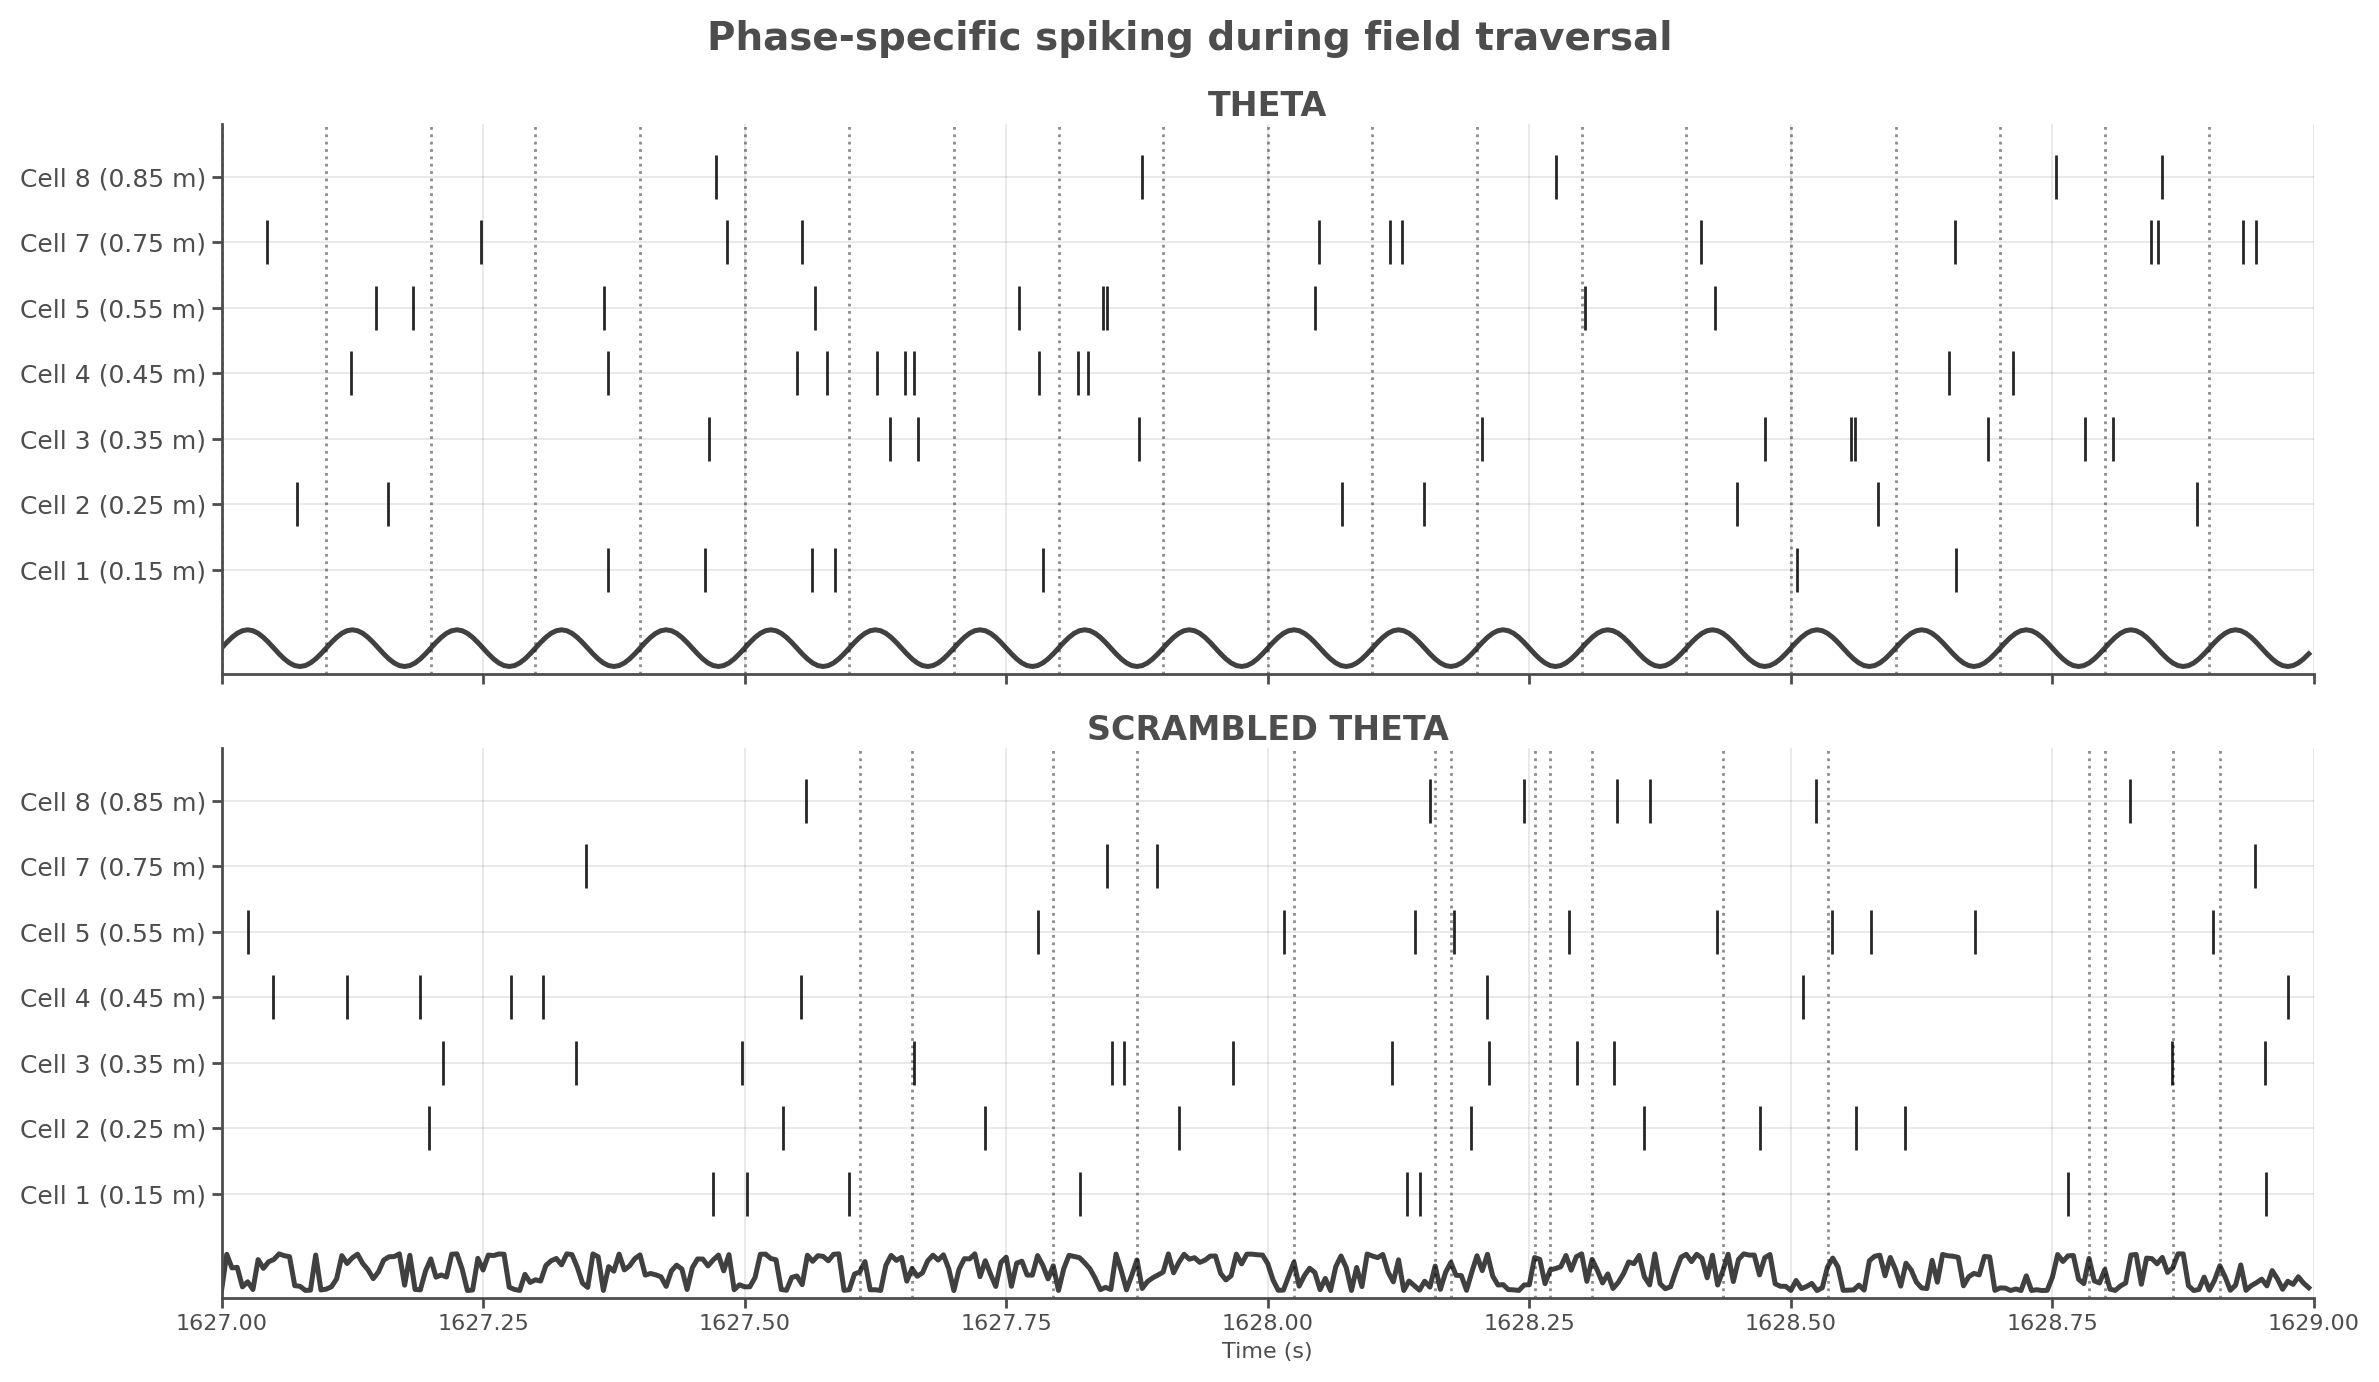

Saved: theta_phase_coding_raster.png


In [10]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt

def plot_theta_sequence_like_reference(
    agent,
    selected_cells=None,          # e.g. [15,20,25,30,35,40,45]
    t_start=5.0,
    t_end=6.2,
    save_path="theta_phase_coding_raster.png"
):
    # ---------- robust getters ----------
    def _get_t_history(a):
        if hasattr(a, "t_history"):
            return np.asarray(a.t_history, dtype=float).reshape(-1)
        return a.history["t"].to_numpy(dtype=float)

    def _get_phase(a, cond_key, t_hist):
        if cond_key == "theta":
            if hasattr(a, "thetaPhase_history"):
                ph = np.asarray(a.thetaPhase_history, dtype=float).reshape(-1)
                return np.mod(ph[:len(t_hist)], 2*np.pi)
            return np.mod(2*np.pi*a.thetaFreq*t_hist, 2*np.pi)

        # scrambled_theta
        if hasattr(a, "thetaPhase_scrambled_history"):
            ph = np.asarray(a.thetaPhase_scrambled_history, dtype=float).reshape(-1)
            return np.mod(ph[:len(t_hist)], 2*np.pi)

        # fallback
        return np.mod(2*np.pi*a.thetaFreq*t_hist, 2*np.pi)

    def _get_ca1(a, cond_key):
        d = a.spikedata_by_condition
        if cond_key in d:
            return d[cond_key]["CA3"]
        if cond_key == "scrambled_theta" and "scrambled" in d:
            return d["scrambled"]["CA3"]
        raise KeyError(f"Condition '{cond_key}' not found in spikedata_by_condition.")

    def _get_spikes(ca3, cell_id):
        # expected format: CA3[cell_id]['times']
        if isinstance(ca3, (list, tuple)):
            return np.asarray(ca3[cell_id]["times"], dtype=float).reshape(-1)

        # alternate format: {'times':..., 'ids':...}
        if isinstance(ca3, dict) and ("times" in ca3) and ("ids" in ca3):
            st = np.asarray(ca3["times"], dtype=float).reshape(-1)
            sid = np.asarray(ca3["ids"], dtype=int).reshape(-1)
            return st[sid == cell_id]

        # dict keyed by cell_id
        if isinstance(ca3, dict) and (cell_id in ca3):
            return np.asarray(ca3[cell_id]["times"], dtype=float).reshape(-1)

        raise TypeError("Unsupported CA3 spike format.")

    # ---------- arrays ----------
    t_hist = _get_t_history(agent)
    centres = np.asarray(agent.centres, dtype=float)

    if selected_cells is None:
        selected_cells = list(np.argsort(centres[:, 0])[20:27])
    else:
        selected_cells = list(selected_cells)

    y_labels = [f"Cell {cid} ({centres[cid,0]:.2f} m)" for cid in selected_cells]
    y_pos = np.arange(len(selected_cells), dtype=float)

    # ---------- figure ----------
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, facecolor="white")
    conditions = [("theta", "THETA"), ("scrambled_theta", "SCRAMBLED THETA")]

    for ax, (cond_key, title_txt) in zip(axes, conditions):
        ph = _get_phase(agent, cond_key, t_hist)
        n = min(len(t_hist), len(ph))
        tt, ph = t_hist[:n], ph[:n]
        m = (tt >= t_start) & (tt <= t_end)

        ca3 = _get_ca1(agent, cond_key)

        # spikes as vertical ticks
        for r, cid in enumerate(selected_cells):
            st = _get_spikes(ca3, int(cid))
            st = st[(st >= t_start) & (st <= t_end)]
            if st.size == 0:
                continue
            ax.scatter(
                st,
                np.full_like(st, y_pos[r], dtype=float),
                marker="|", s=260, c="black", alpha=0.85, linewidths=1.0
            )

        # top theta trace inside each panel
        y_theta = -1.2 + 0.28 * np.sin(ph[m])
        ax.plot(tt[m], y_theta, color="black", lw=1.8, alpha=0.75)

        # cycle boundaries
        wraps = np.where((ph[:-1] > 5.0) & (ph[1:] < 1.0))[0] + 1
        t_wrap = tt[wraps]
        t_wrap = t_wrap[(t_wrap >= t_start) & (t_wrap <= t_end)]
        for xc in t_wrap:
            ax.axvline(xc, color="black", ls=":", lw=1.0, alpha=0.45)

        ax.set_title(title_txt, fontsize=12, fontweight="bold")
        ax.set_facecolor("white")
        ax.grid(True, color="black", alpha=0.10, linewidth=0.6)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(y_labels, fontsize=9)
        ax.set_ylim(-1.6, len(selected_cells) - 0.2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xlim(t_start, t_end)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle("Phase-specific spiking during field traversal", fontsize=14, fontweight="bold", y=0.98)
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {save_path}")

# run
plot_theta_sequence_like_reference(
    agent_p,
    selected_cells=[1, 2, 3, 4, 5, 7, 8],
    t_start=1627.0,
    t_end=1629.0,
    save_path="theta_phase_coding_raster.png"
)
# ...existing code...